# Tratamiento Completo de Series Temporales (Versión Ampliada)
Este notebook cubre teoría fundamental, modelos avanzados, evaluación, división adecuada de datos, selección de hiperparámetros y ejercicios completos.

# 1. Conceptos fundamentales de series temporales

## ¿Qué es una serie temporal?
Una serie temporal presenta tendencia, estacionalidad, ciclos y ruido. Estos componentes permiten describir su comportamiento y seleccionar modelos apropiados.    

Una **serie temporal** es un conjunto de observaciones ordenadas en el tiempo. Cada dato tiene asociado un instante temporal. Algunos ejemplos comunes son:
* Temperatura diaria
* Ventas mensuales de una empresa
* Señales biométricas (ritmo cardíaco, acelerometría, etc.)
* Tráfico en una web por horas

Las series temporales suelen presentar patrones como:
* **Tendencia**: evolución creciente o decreciente a largo plazo.
* **Estacionalidad**: fluctuaciones periódicas.
* **Ciclo**: movimientos amplios relacionados con factores externos.
* **Ruido**: variabilidad aleatoria sin patrón visible.

# 2. Crear una serie temporal realista

Text(0.5, 1.0, 'Serie temporal simulada')

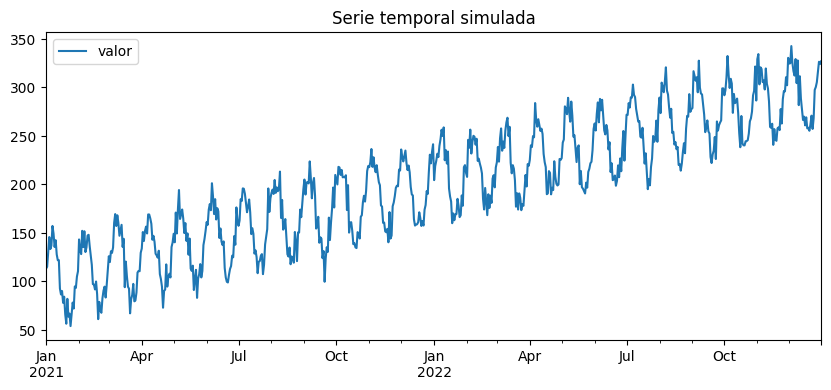

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fechas = pd.date_range('2021-01-01', periods=730, freq='D')
tendencia = np.linspace(100, 300, 730)
estacionalidad = 40 * np.sin(2 * np.pi * fechas.dayofyear / 30)
ruido = np.random.normal(0, 10, 730)
serie = pd.DataFrame({'valor': tendencia + estacionalidad + ruido}, index=fechas)
serie.plot(figsize=(10,4))
plt.title('Serie temporal simulada')

# 3. Descomposición

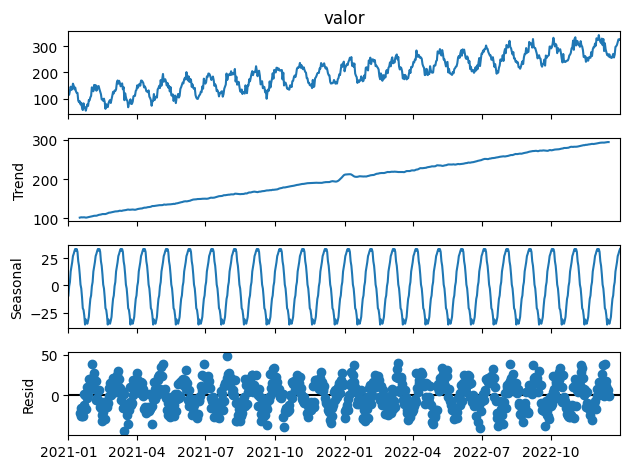

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomp = seasonal_decompose(serie['valor'], model='additive', period=30)
descomp.plot();

# 4. Suavizado (medias móviles)

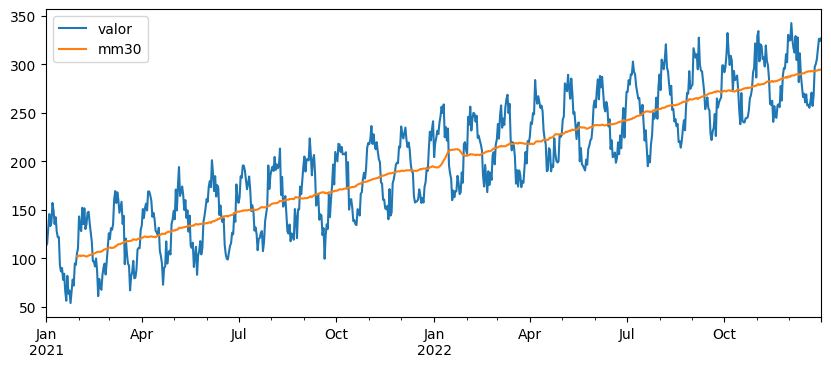

In [3]:
serie['mm30'] = serie['valor'].rolling(30).mean()
serie[['valor','mm30']].plot(figsize=(10,4));

# 5. Estacionariedad y diferenciación

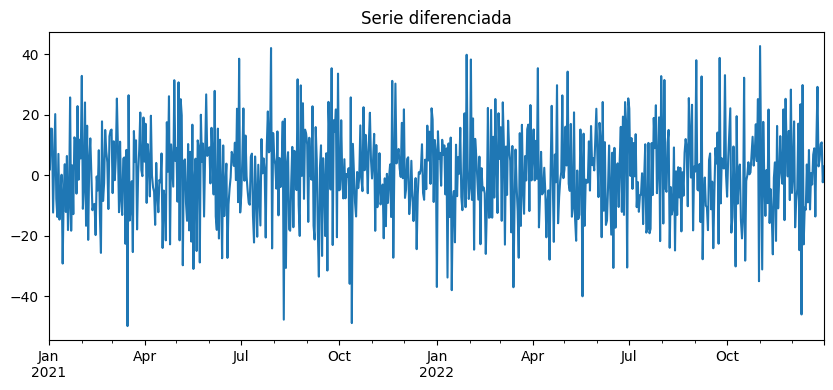

In [4]:
serie['diff'] = serie['valor'].diff()
serie['diff'].plot(figsize=(10,4)); plt.title('Serie diferenciada');

# 6. ACF y PACF

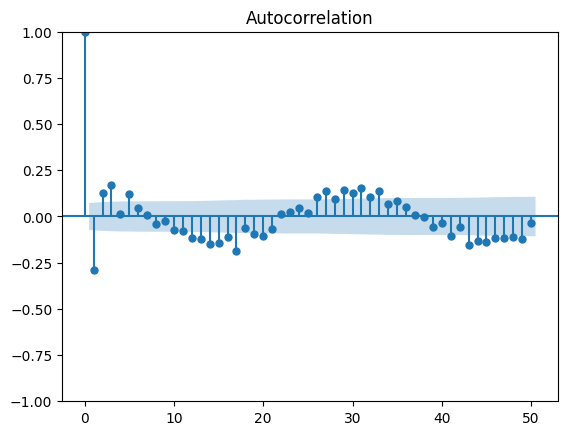

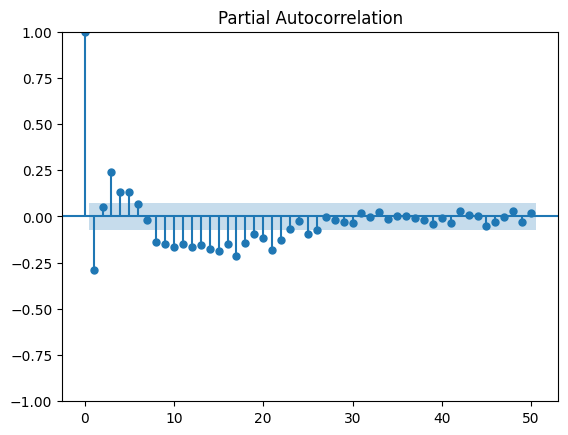

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(serie['diff'].dropna(), lags=50); plt.show()
plot_pacf(serie['diff'].dropna(), lags=50); plt.show()

# 7. División Train/Test adecuada (sin mezcla temporal)

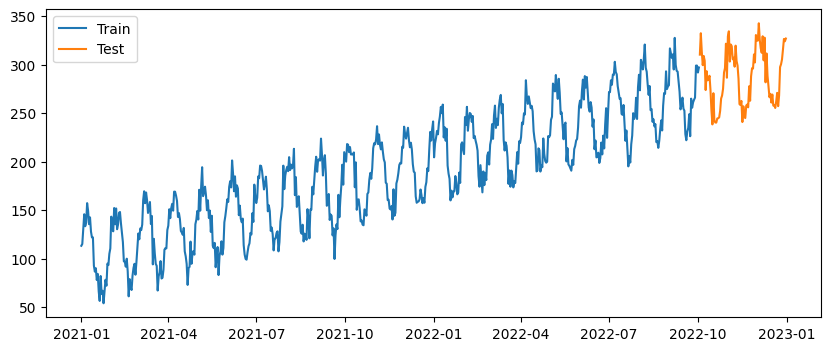

In [6]:
train = serie.iloc[:-90]
test = serie.iloc[-90:]

plt.figure(figsize=(10,4))
plt.plot(train.index, train['valor'], label='Train')
plt.plot(test.index, test['valor'], label='Test')
plt.legend();

# 8. Modelo ARIMA

In [7]:
from statsmodels.tsa.arima.model import ARIMA

modelo_arima = ARIMA(train['valor'], order=(2,1,2))
fit_arima = modelo_arima.fit()
fit_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  valor   No. Observations:                  640
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2581.256
Date:                Mon, 24 Nov 2025   AIC                           5172.512
Time:                        18:51:23   BIC                           5194.811
Sample:                    01-01-2021   HQIC                          5181.168
                         - 10-02-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0036      0.077     13.008      0.000       0.852       1.155
ar.L2         -0.1936      0.076     -2.538      0.011      -0.343      -0.044
ma.L1         -1.3504      0.055    -24.775      0.000      -1.457      -1.244
ma.L2          0.6519      0.053     12.271      0.000       0.548       0.756
sigma2       188.6811     10.591     17.816      0.000     167.924     209.439
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 0.83
Prob(Q):                              0.75   Prob(JB):                         0.66
Heteroskedasticity (H):               1.10   Skew:                            -0.08
Prob(H) (two-sided):                  0.48   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# 9. Predicción ARIMA y evaluación

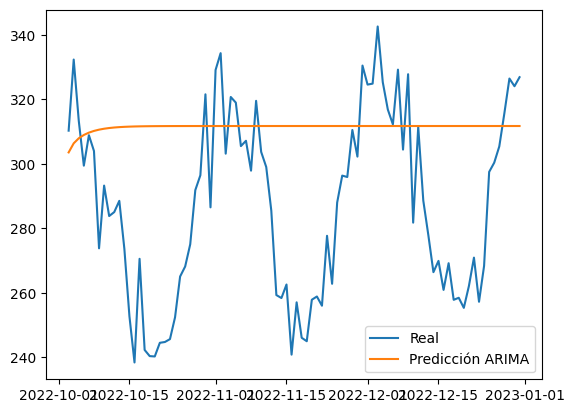

In [8]:
pred_arima = fit_arima.forecast(steps=len(test))

plt.plot(test.index, test['valor'], label='Real')
plt.plot(test.index, pred_arima, label='Predicción ARIMA')
plt.legend();

## Métricas de evaluación

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['valor'], pred_arima)
rmse = np.sqrt(mean_squared_error(test['valor'], pred_arima))
mae, rmse

ModuleNotFoundError: No module named 'sklearn'

# 10. Modelo SARIMA (estacional)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarima = SARIMAX(train['valor'], order=(2,1,2), seasonal_order=(1,1,1,30))
fit_sarima = modelo_sarima.fit()
fit_sarima.summary()

# 11. Búsqueda de hiperparámetros (Grid Search para ARIMA/SARIMA)

In [ ]:
import itertools

p = d = q = range(0,3)
pdq = list(itertools.product(p,d,q))
best_aic = np.inf
best_cfg = None

for cfg in pdq:
    try:
        model = ARIMA(train['valor'], order=cfg)
        fit = model.fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_cfg = cfg
    except Exception:
        pass

best_cfg, best_aic

# 12. Prophet

In [ ]:
from prophet import Prophet

df_p = serie.reset_index().rename(columns={'index':'ds','valor':'y'})
prophet_model = Prophet()
prophet_model.fit(df_p)
future = prophet_model.make_future_dataframe(periods=60)
forecast = prophet_model.predict(future)
prophet_model.plot(forecast);

# 13. LSTM (Red Neuronal) con evaluación

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

scaler = MinMaxScaler()
scaled = scaler.fit_transform(serie[['valor']])

X, y = [], []
for i in range(60, len(scaled)):
    X.append(scaled[i-60:i])
    y.append(scaled[i])
X, y = np.array(X), np.array(y)

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True),
    tf.keras.layers.LSTM(50),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=5, batch_size=32, verbose=0)

# 14. Ejercicios Finales

1. Crea una serie con tendencia exponencial, estacionalidad multiplicativa y ruido.
2. Evalúa estacionariedad con Dickey-Fuller.
3. Aplica medias móviles y comenta los cambios observados.
4. Realiza ACF/PACF y propone valores para (p,d,q).
5. Haz un Grid Search real con ARIMA.
6. Compara ARIMA, SARIMA, Prophet y LSTM en términos de RMSE.
7. Usa un dataset real y repite todo el flujo completo.